In [1]:
!pip -q install xgboost joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import joblib

warnings.filterwarnings("ignore")

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from xgboost import XGBRegressor

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
from google.colab import files

uploaded = files.upload()

Saving Toronto Island Ferry Tickets.csv to Toronto Island Ferry Tickets (1).csv


In [13]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (261538, 4)


,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [14]:
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Rows: 261538
Columns: ['_id', 'Timestamp', 'Redemption Count', 'Sales Count']

Data Types:
_id                  int64
Timestamp           object
Redemption Count     int64
Sales Count          int64
dtype: object

Missing Values:
_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

Duplicate Rows:
0


In [15]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df = df.sort_values("Timestamp").reset_index(drop=True)

print("Minimum timestamp:", df["Timestamp"].min())
print("Maximum timestamp:", df["Timestamp"].max())

display(df.head())

Minimum timestamp: 2015-05-01 13:30:00
Maximum timestamp: 2025-12-21 22:30:00


,_id,Timestamp,Redemption Count,Sales Count
0,261538,2015-05-01 13:30:00,0,1
1,261537,2015-05-01 15:15:00,0,2
2,261536,2015-05-01 15:45:00,0,1
3,261535,2015-05-01 16:00:00,1,0
4,261534,2015-05-04 16:00:00,0,2


In [16]:
df["Time_Difference"] = df["Timestamp"].diff()

print("Time gap distribution:")
display(df["Time_Difference"].value_counts().head(20))

Time gap distribution:


,count
Time_Difference,
0 days 00:15:00,236262
0 days 00:30:00,13415
0 days 00:45:00,4407
0 days 01:00:00,1834
0 days 01:15:00,782
0 days 01:30:00,526
0 days 07:00:00,469
0 days 01:45:00,363
0 days 02:00:00,304


In [18]:
df["Total_Demand"] = (
    df["Sales Count"] +
    df["Redemption Count"]
)

df["Sales_Redemption_Gap"] = (
    df["Sales Count"] -
    df["Redemption Count"]
)

df["Redemption_Ratio"] = np.where(
    df["Sales Count"] > 0,
    df["Redemption Count"] / df["Sales Count"],
    0
)

df["Demand_per_Ticket_Type"] = (
    df["Total_Demand"] / 2
)

display(
    df[
        [
            "Timestamp",
            "Sales Count",
            "Redemption Count",
            "Total_Demand",
            "Sales_Redemption_Gap",
            "Redemption_Ratio"
        ]
    ].head(20)
)

,Timestamp,Sales Count,Redemption Count,Total_Demand,Sales_Redemption_Gap,Redemption_Ratio
0,2015-05-01 13:30:00,1,0,1,1,0.000000
1,2015-05-01 15:15:00,2,0,2,2,0.000000
2,2015-05-01 15:45:00,1,0,1,1,0.000000
3,2015-05-01 16:00:00,0,1,1,-1,0.000000
4,2015-05-04 16:00:00,2,0,2,2,0.000000
5,2015-05-04 16:15:00,2,0,2,2,0.000000
6,2015-05-04 16:30:00,3,0,3,3,0.000000
7,2015-05-04 16:45:00,3,0,3,3,0.000000
8,2015-05-04 17:00:00,6,4,10,2,0.666667
9,2015-05-04 17:15:00,11,8,19,3,0.727273


In [19]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["DayOfYear"] = df["Timestamp"].dt.dayofyear

df["Hour"] = df["Timestamp"].dt.hour
df["Minute"] = df["Timestamp"].dt.minute

df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

df["WeekOfYear"] = df["Timestamp"].dt.isocalendar().week.astype(int)

df["Quarter"] = df["Timestamp"].dt.quarter

df["Is_Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

df["Is_Morning"] = (
    (df["Hour"] >= 6) &
    (df["Hour"] < 12)
).astype(int)

df["Is_Afternoon"] = (
    (df["Hour"] >= 12) &
    (df["Hour"] < 17)
).astype(int)

df["Is_Evening"] = (
    (df["Hour"] >= 17) &
    (df["Hour"] < 22)
).astype(int)

df["Is_Night"] = (
    (df["Hour"] >= 22) |
    (df["Hour"] < 6)
).astype(int)

In [20]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df["Is_Summer"] = (
    df["Month"].isin([6, 7, 8])
).astype(int)

df["Is_Peak_Season"] = (
    df["Month"].isin([5, 6, 7, 8, 9])
).astype(int)

display(df[["Timestamp", "Month", "Season", "Is_Peak_Season"]].head())

,Timestamp,Month,Season,Is_Peak_Season
0,2015-05-01 13:30:00,5,Spring,1
1,2015-05-01 15:15:00,5,Spring,1
2,2015-05-01 15:45:00,5,Spring,1
3,2015-05-01 16:00:00,5,Spring,1
4,2015-05-04 16:00:00,5,Spring,1


In [21]:
df["Hour_Sin"] = np.sin(
    2 * np.pi * df["Hour"] / 24
)

df["Hour_Cos"] = np.cos(
    2 * np.pi * df["Hour"] / 24
)

df["Day_Sin"] = np.sin(
    2 * np.pi * df["DayOfWeek"] / 7
)

df["Day_Cos"] = np.cos(
    2 * np.pi * df["DayOfWeek"] / 7
)

df["Month_Sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["Month_Cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)

df["Year_Sin"] = np.sin(
    2 * np.pi * df["DayOfYear"] / 365.25
)

df["Year_Cos"] = np.cos(
    2 * np.pi * df["DayOfYear"] / 365.25
)

In [22]:
df = df.sort_values("Timestamp").reset_index(drop=True)

df["Time_Difference"] = df["Timestamp"].diff()

df["New_Sequence"] = (
    df["Time_Difference"] != pd.Timedelta(minutes=15)
).astype(int)

df["Sequence_ID"] = df["New_Sequence"].cumsum()

print("Number of continuous sequences:",
      df["Sequence_ID"].nunique())

Number of continuous sequences: 25276


In [23]:
grouped = df.groupby("Sequence_ID")["Total_Demand"]

lag_values = [1, 2, 4, 8, 12, 16]

for lag in lag_values:
    df[f"Lag_{lag}"] = grouped.shift(lag)

In [24]:
for lag in [1, 2, 4, 8]:

    df[f"Sales_Lag_{lag}"] = (
        df.groupby("Sequence_ID")["Sales Count"]
        .shift(lag)
    )

    df[f"Redemption_Lag_{lag}"] = (
        df.groupby("Sequence_ID")["Redemption Count"]
        .shift(lag)
    )

In [25]:
grouped_demand = df.groupby("Sequence_ID")["Total_Demand"]

for window in [2, 4, 8, 12, 16]:

    df[f"Rolling_Mean_{window}"] = (
        grouped_demand
        .transform(
            lambda x: x.shift(1).rolling(window).mean()
        )
    )

    df[f"Rolling_Std_{window}"] = (
        grouped_demand
        .transform(
            lambda x: x.shift(1).rolling(window).std()
        )
    )

    df[f"Rolling_Max_{window}"] = (
        grouped_demand
        .transform(
            lambda x: x.shift(1).rolling(window).max()
        )
    )

    df[f"Rolling_Min_{window}"] = (
        grouped_demand
        .transform(
            lambda x: x.shift(1).rolling(window).min()
        )
    )

In [26]:
df["Demand_Momentum_15m"] = (
    df["Lag_1"] - df["Lag_2"]
)

df["Demand_Momentum_30m"] = (
    df["Lag_2"] - df["Lag_4"]
)

df["Demand_Momentum_1h"] = (
    df["Lag_4"] - df["Lag_8"]
)

In [27]:
df["Demand_Acceleration"] = (
    df["Demand_Momentum_15m"] -
    df["Demand_Momentum_30m"]
)

In [28]:
df["Demand_Volatility"] = (
    df["Rolling_Std_8"] /
    (df["Rolling_Mean_8"] + 1)
)

df["Demand_Volatility"] = (
    df["Demand_Volatility"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [29]:
demand_q75 = df["Total_Demand"].quantile(0.75)
demand_q90 = df["Total_Demand"].quantile(0.90)
demand_q95 = df["Total_Demand"].quantile(0.95)

df["High_Demand_Flag"] = (
    df["Total_Demand"] >= demand_q75
).astype(int)

df["Demand_Spike"] = (
    df["Total_Demand"] >= demand_q90
).astype(int)

df["Extreme_Demand"] = (
    df["Total_Demand"] >= demand_q95
).astype(int)

print("75th percentile:", demand_q75)
print("90th percentile:", demand_q90)
print("95th percentile:", demand_q95)

75th percentile: 88.0
90th percentile: 288.0
95th percentile: 494.0


In [30]:
df["Time_Block"] = (
    df["Hour"] * 4 +
    (df["Minute"] // 15)
)

historical_mean = (
    df.groupby(["DayOfWeek", "Time_Block"])["Total_Demand"]
    .transform("mean")
)

df["Historical_Time_Demand"] = historical_mean

In [31]:
df["Trend_1h"] = (
    df["Lag_1"] -
    df["Lag_4"]
)

df["Trend_2h"] = (
    df["Lag_1"] -
    df["Lag_8"]
)

In [32]:
HORIZONS = {
    "15min": 1,
    "30min": 2,
    "1hour": 4,
    "2hour": 8
}

for name, steps in HORIZONS.items():

    df[f"Target_{name}"] = (
        df.groupby("Sequence_ID")["Total_Demand"]
        .shift(-steps)
    )

print(
    df[
        [
            "Timestamp",
            "Total_Demand",
            "Target_15min",
            "Target_30min",
            "Target_1hour",
            "Target_2hour"
        ]
    ].head(20)
)

             Timestamp  Total_Demand  Target_15min  Target_30min  \
0  2015-05-01 13:30:00             1           NaN           NaN   
1  2015-05-01 15:15:00             2           NaN           NaN   
2  2015-05-01 15:45:00             1           1.0           NaN   
3  2015-05-01 16:00:00             1           NaN           NaN   
4  2015-05-04 16:00:00             2           2.0           3.0   
5  2015-05-04 16:15:00             2           3.0           3.0   
6  2015-05-04 16:30:00             3           3.0          10.0   
7  2015-05-04 16:45:00             3          10.0          19.0   
8  2015-05-04 17:00:00            10          19.0           7.0   
9  2015-05-04 17:15:00            19           7.0           7.0   
10 2015-05-04 17:30:00             7           7.0           NaN   
11 2015-05-04 17:45:00             7           NaN           NaN   
12 2015-05-04 18:15:00             1           NaN           NaN   
13 2015-05-04 18:45:00             1           2

In [33]:
FEATURES = [
    # Current demand
    "Total_Demand",
    "Sales Count",
    "Redemption Count",
    "Sales_Redemption_Gap",
    "Redemption_Ratio",

    # Calendar
    "Year",
    "Month",
    "Day",
    "DayOfYear",
    "Hour",
    "Minute",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    # Time categories
    "Is_Weekend",
    "Is_Morning",
    "Is_Afternoon",
    "Is_Evening",
    "Is_Night",
    "Is_Summer",
    "Is_Peak_Season",

    # Cyclical
    "Hour_Sin",
    "Hour_Cos",
    "Day_Sin",
    "Day_Cos",
    "Month_Sin",
    "Month_Cos",
    "Year_Sin",
    "Year_Cos",

    # Lags
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Lag_12",
    "Lag_16",

    # Sales / redemption lags
    "Sales_Lag_1",
    "Sales_Lag_2",
    "Sales_Lag_4",
    "Sales_Lag_8",

    "Redemption_Lag_1",
    "Redemption_Lag_2",
    "Redemption_Lag_4",
    "Redemption_Lag_8",

    # Rolling
    "Rolling_Mean_2",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12",
    "Rolling_Mean_16",

    "Rolling_Std_2",
    "Rolling_Std_4",
    "Rolling_Std_8",
    "Rolling_Std_12",
    "Rolling_Std_16",

    "Rolling_Max_4",
    "Rolling_Max_8",
    "Rolling_Max_16",

    "Rolling_Min_4",
    "Rolling_Min_8",
    "Rolling_Min_16",

    # Momentum
    "Demand_Momentum_15m",
    "Demand_Momentum_30m",
    "Demand_Momentum_1h",

    # Acceleration
    "Demand_Acceleration",

    # Volatility
    "Demand_Volatility",

    # Historical pattern
    "Historical_Time_Demand",

    # Trend
    "Trend_1h",
    "Trend_2h"
]

print("Total engineered features:", len(FEATURES))

Total engineered features: 67


In [34]:
model_df = df.copy()

target_columns = [
    "Target_15min",
    "Target_30min",
    "Target_1hour",
    "Target_2hour"
]

required_columns = FEATURES + target_columns

model_df = model_df.dropna(
    subset=required_columns
).copy()

print("Original rows:", len(df))
print("Model rows:", len(model_df))
print("Features:", len(FEATURES))

Original rows: 261538
Model rows: 107823
Features: 67


In [35]:
split_date = model_df["Timestamp"].quantile(0.80)

train_df = model_df[
    model_df["Timestamp"] < split_date
].copy()

test_df = model_df[
    model_df["Timestamp"] >= split_date
].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nTrain period:")
print(train_df["Timestamp"].min(), "to", train_df["Timestamp"].max())

print("\nTest period:")
print(test_df["Timestamp"].min(), "to", test_df["Timestamp"].max())

Train: (86258, 86)
Test : (21565, 86)

Train period:
2015-05-05 11:00:00 to 2024-05-13 16:15:00

Test period:
2024-05-13 16:30:00 to 2025-12-21 17:30:00


In [36]:
X_train = train_df[FEATURES]
X_test = test_df[FEATURES]

y_train = {}
y_test = {}

for horizon in HORIZONS:

    y_train[horizon] = train_df[
        f"Target_{horizon}"
    ]

    y_test[horizon] = test_df[
        f"Target_{horizon}"
    ]

print("Training data prepared.")

Training data prepared.


In [37]:
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

print("Models created.")

Models created.


In [38]:
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    # Safe MAPE
    denominator = np.maximum(
        np.abs(actual),
        1
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) /
            denominator
        )
    ) * 100

    return mae, rmse, mape

In [39]:
results = []

trained_models = {}

for horizon in HORIZONS:

    print("\n" + "="*60)
    print("HORIZON:", horizon)
    print("="*60)

    trained_models[horizon] = {}

    for model_name, model in models.items():

        print("Training:", model_name)

        model.fit(
            X_train,
            y_train[horizon]
        )

        predictions = model.predict(X_test)

        mae, rmse, mape = calculate_metrics(
            y_test[horizon],
            predictions
        )

        results.append({
            "Horizon": horizon,
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

        trained_models[horizon][model_name] = model

        print(
            f"MAE={mae:.2f} | "
            f"RMSE={rmse:.2f} | "
            f"MAPE={mape:.2f}%"
        )


HORIZON: 15min
Training: Linear Regression
MAE=50.66 | RMSE=169.62 | MAPE=68.55%
Training: Random Forest
MAE=50.62 | RMSE=171.99 | MAPE=69.81%
Training: Gradient Boosting
MAE=47.57 | RMSE=167.22 | MAPE=64.94%
Training: XGBoost
MAE=49.68 | RMSE=170.46 | MAPE=70.25%

HORIZON: 30min
Training: Linear Regression
MAE=51.29 | RMSE=170.40 | MAPE=72.32%
Training: Random Forest
MAE=48.47 | RMSE=168.16 | MAPE=67.56%
Training: Gradient Boosting
MAE=49.66 | RMSE=168.61 | MAPE=73.72%
Training: XGBoost
MAE=48.97 | RMSE=168.86 | MAPE=71.35%

HORIZON: 1hour
Training: Linear Regression
MAE=53.69 | RMSE=179.29 | MAPE=87.64%
Training: Random Forest
MAE=48.58 | RMSE=177.28 | MAPE=78.66%
Training: Gradient Boosting
MAE=48.99 | RMSE=175.51 | MAPE=82.35%
Training: XGBoost
MAE=47.78 | RMSE=175.50 | MAPE=72.77%

HORIZON: 2hour
Training: Linear Regression
MAE=55.68 | RMSE=185.11 | MAPE=144.97%
Training: Random Forest
MAE=44.86 | RMSE=178.50 | MAPE=86.08%
Training: Gradient Boosting
MAE=46.87 | RMSE=179.03 | MAP

In [40]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["Horizon", "RMSE"]
)

display(results_df)

,Horizon,Model,MAE,RMSE,MAPE
2,15min,Gradient Boosting,47.566217,167.216651,64.941801
0,15min,Linear Regression,50.658521,169.617574,68.554043
3,15min,XGBoost,49.682734,170.461496,70.254864
1,15min,Random Forest,50.622656,171.989125,69.809590
11,1hour,XGBoost,47.775382,175.504499,72.767164
10,1hour,Gradient Boosting,48.988292,175.507566,82.345512
9,1hour,Random Forest,48.579225,177.276668,78.657564
8,1hour,Linear Regression,53.689245,179.293981,87.636343
15,2hour,XGBoost,44.886858,177.885050,90.340946
13,2hour,Random Forest,44.859650,178.499212,86.076676


In [41]:
best_models = {}

for horizon in HORIZONS:

    temp = results_df[
        results_df["Horizon"] == horizon
    ]

    best_row = temp.loc[
        temp["RMSE"].idxmin()
    ]

    best_models[horizon] = best_row["Model"]

print("BEST MODELS")
print("="*50)

for horizon, model_name in best_models.items():

    print(
        f"{horizon}: {model_name}"
    )

BEST MODELS
15min: Gradient Boosting
30min: Random Forest
1hour: XGBoost
2hour: XGBoost


In [42]:
baseline_results = []

for horizon, steps in HORIZONS.items():

    actual = y_test[horizon]

    # Current demand is used as the forecast
    baseline_prediction = test_df["Total_Demand"].values

    mae, rmse, mape = calculate_metrics(
        actual,
        baseline_prediction
    )

    baseline_results.append({
        "Horizon": horizon,
        "Model": "Naive Forecast",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

baseline_df = pd.DataFrame(
    baseline_results
)

display(baseline_df)

,Horizon,Model,MAE,RMSE,MAPE
0,15min,Naive Forecast,62.714769,222.041448,81.717567
1,30min,Naive Forecast,65.334013,223.482436,84.616063
2,1hour,Naive Forecast,70.778716,233.022993,103.824162
3,2hour,Naive Forecast,88.793833,248.243773,218.204736


In [43]:
final_results = pd.concat(
    [
        results_df,
        baseline_df
    ],
    ignore_index=True
)

final_results = final_results.sort_values(
    ["Horizon", "RMSE"]
)

display(final_results)

,Horizon,Model,MAE,RMSE,MAPE
0,15min,Gradient Boosting,47.566217,167.216651,64.941801
1,15min,Linear Regression,50.658521,169.617574,68.554043
2,15min,XGBoost,49.682734,170.461496,70.254864
3,15min,Random Forest,50.622656,171.989125,69.809590
16,15min,Naive Forecast,62.714769,222.041448,81.717567
4,1hour,XGBoost,47.775382,175.504499,72.767164
5,1hour,Gradient Boosting,48.988292,175.507566,82.345512
6,1hour,Random Forest,48.579225,177.276668,78.657564
7,1hour,Linear Regression,53.689245,179.293981,87.636343
18,1hour,Naive Forecast,70.778716,233.022993,103.824162


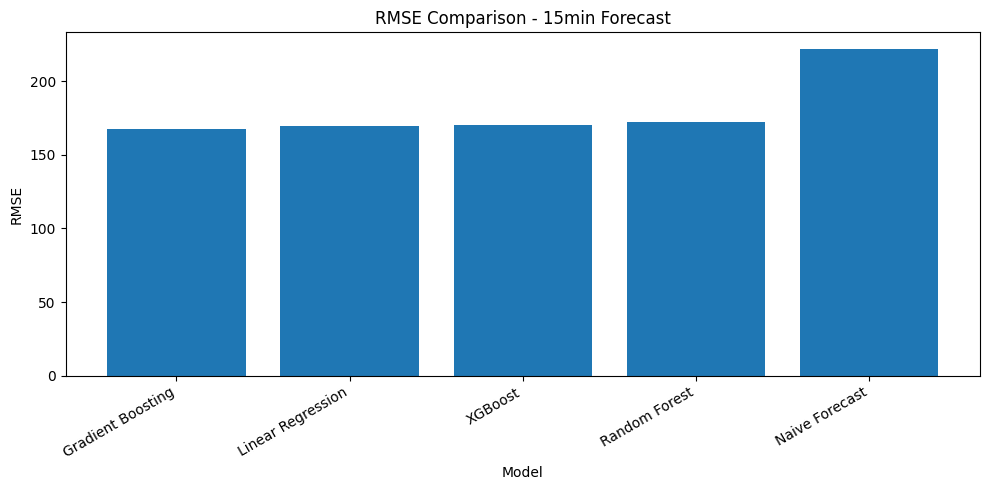

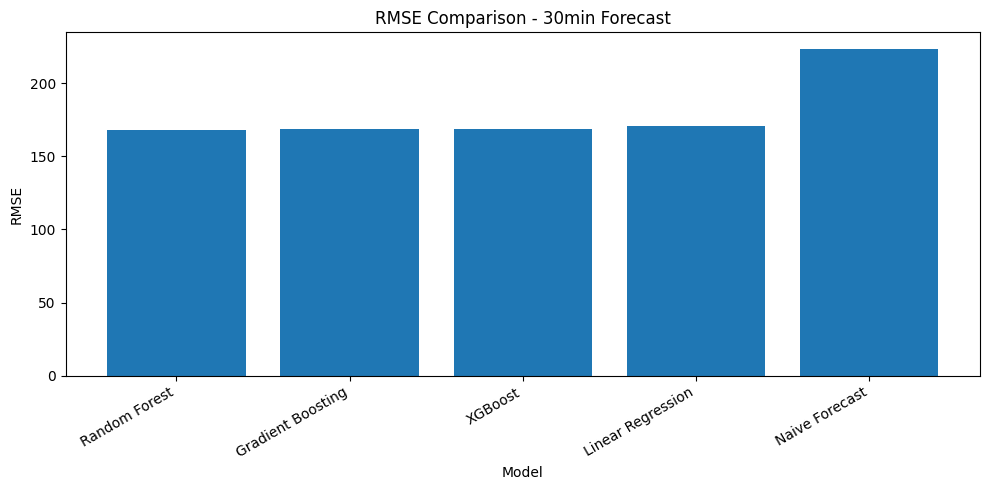

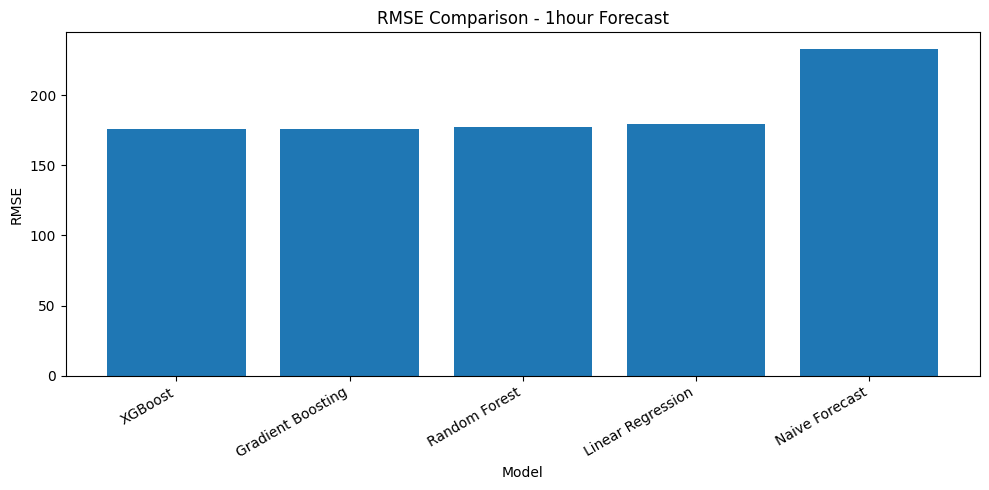

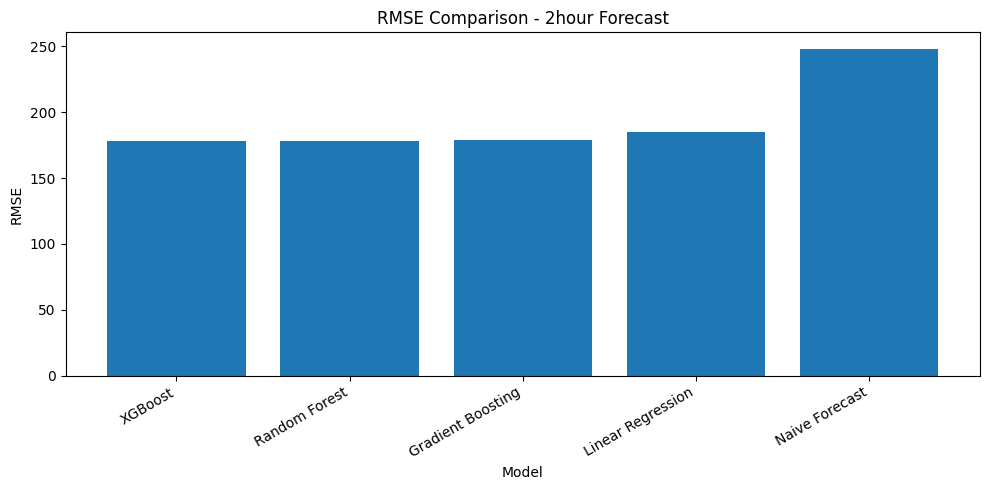

In [44]:
for horizon in HORIZONS:

    temp = final_results[
        final_results["Horizon"] == horizon
    ].sort_values("RMSE")

    plt.figure(figsize=(10, 5))

    plt.bar(
        temp["Model"],
        temp["RMSE"]
    )

    plt.title(
        f"RMSE Comparison - {horizon} Forecast"
    )

    plt.ylabel("RMSE")
    plt.xlabel("Model")

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

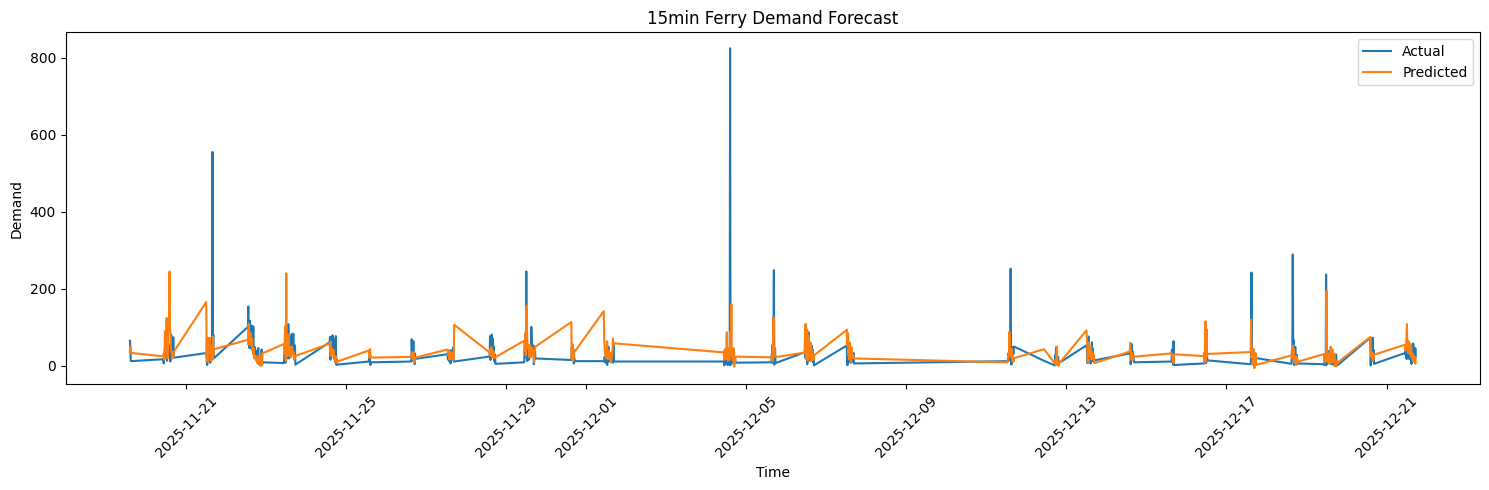

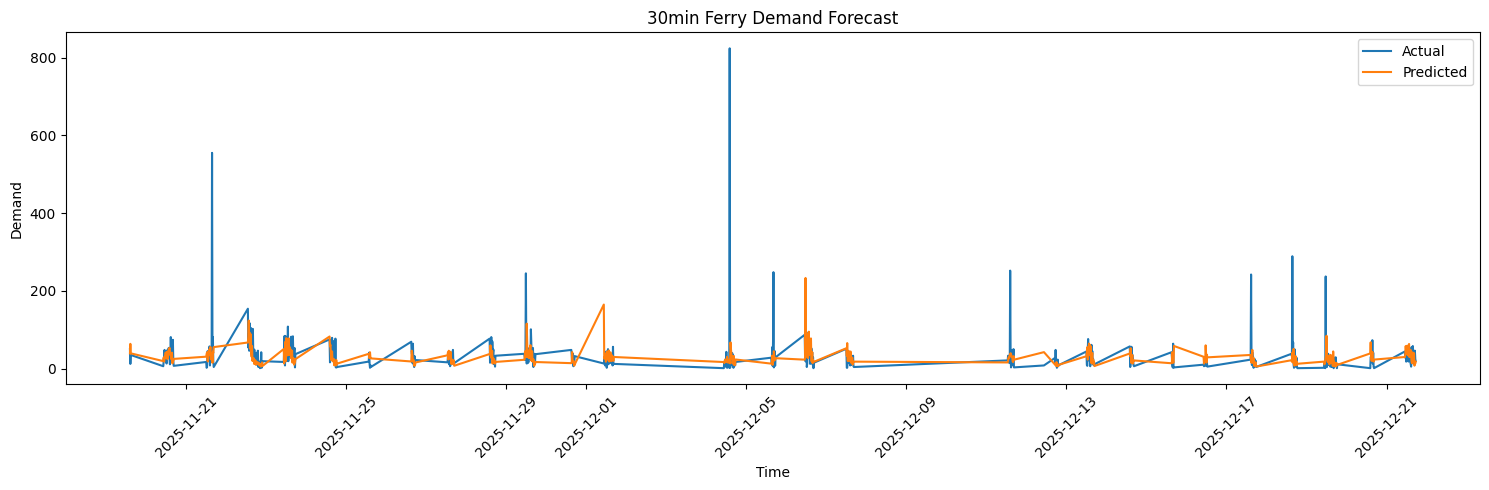

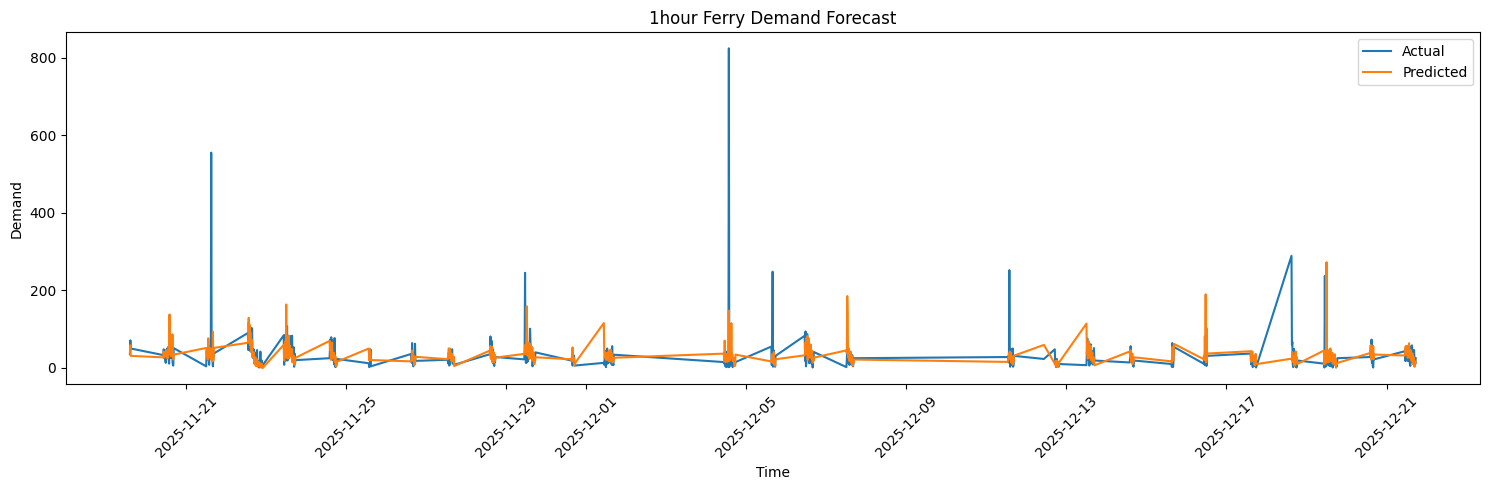

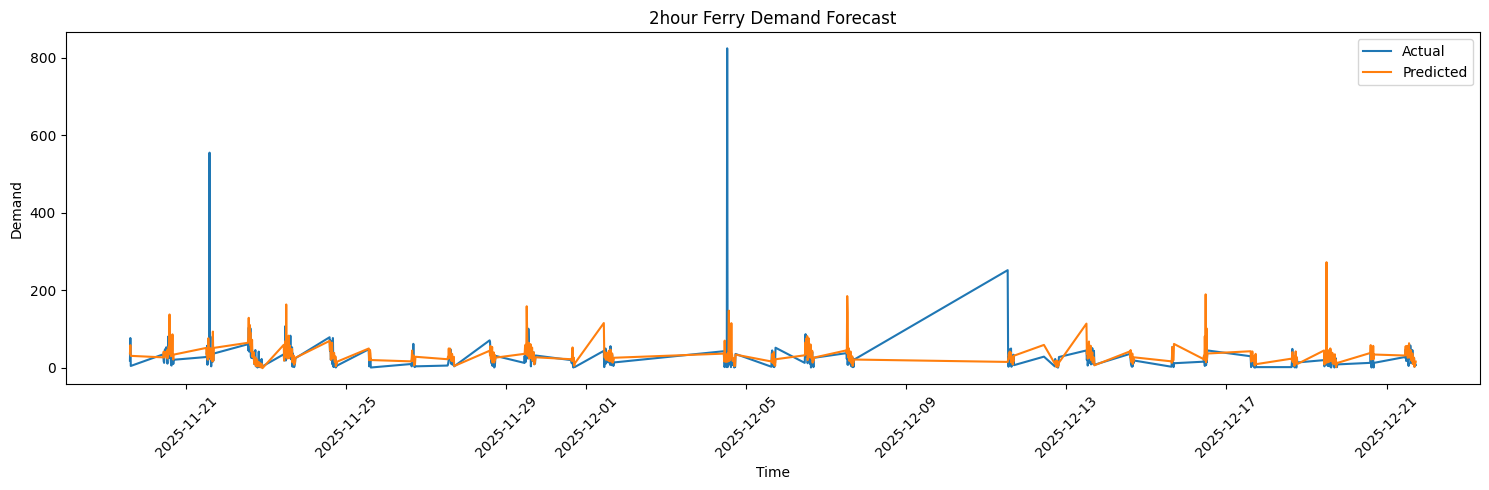

In [45]:
for horizon in HORIZONS:

    best_model_name = best_models[horizon]

    model = trained_models[
        horizon
    ][best_model_name]

    predictions = model.predict(X_test)

    plot_df = pd.DataFrame({
        "Timestamp": test_df["Timestamp"].values,
        "Actual": y_test[horizon].values,
        "Predicted": predictions
    })

    plot_df = plot_df.tail(500)

    plt.figure(figsize=(15, 5))

    plt.plot(
        plot_df["Timestamp"],
        plot_df["Actual"],
        label="Actual"
    )

    plt.plot(
        plot_df["Timestamp"],
        plot_df["Predicted"],
        label="Predicted"
    )

    plt.title(
        f"{horizon} Ferry Demand Forecast"
    )

    plt.xlabel("Time")
    plt.ylabel("Demand")

    plt.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

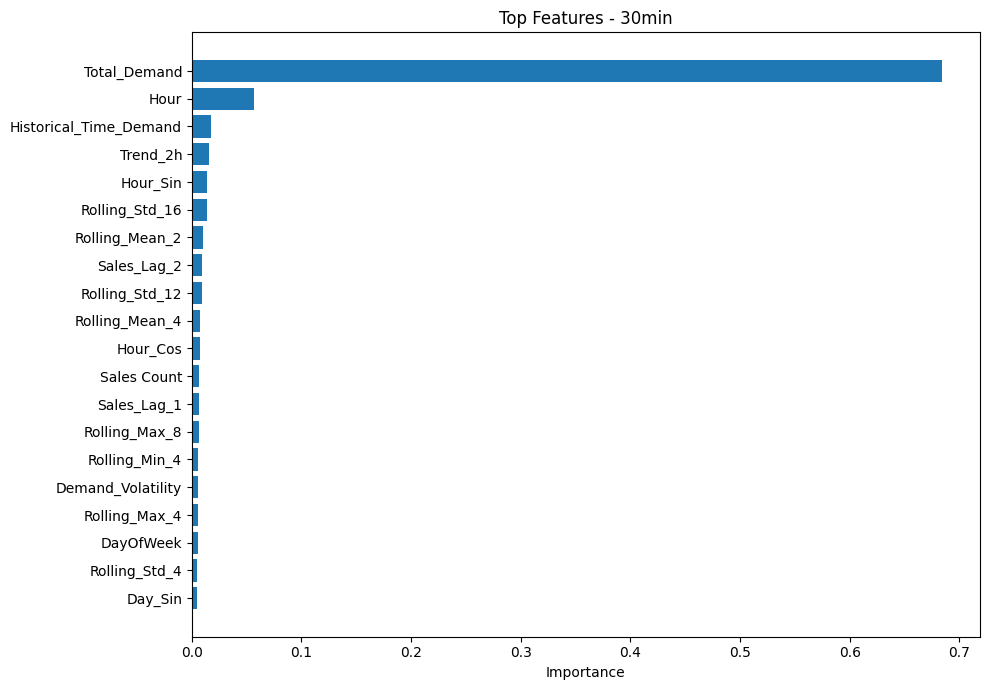

,Feature,Importance
0,Total_Demand,0.684595
9,Hour,0.057038
64,Historical_Time_Demand,0.017509
66,Trend_2h,0.015406
21,Hour_Sin,0.013927
52,Rolling_Std_16,0.013461
43,Rolling_Mean_2,0.010430
36,Sales_Lag_2,0.009521
51,Rolling_Std_12,0.008816
44,Rolling_Mean_4,0.007508


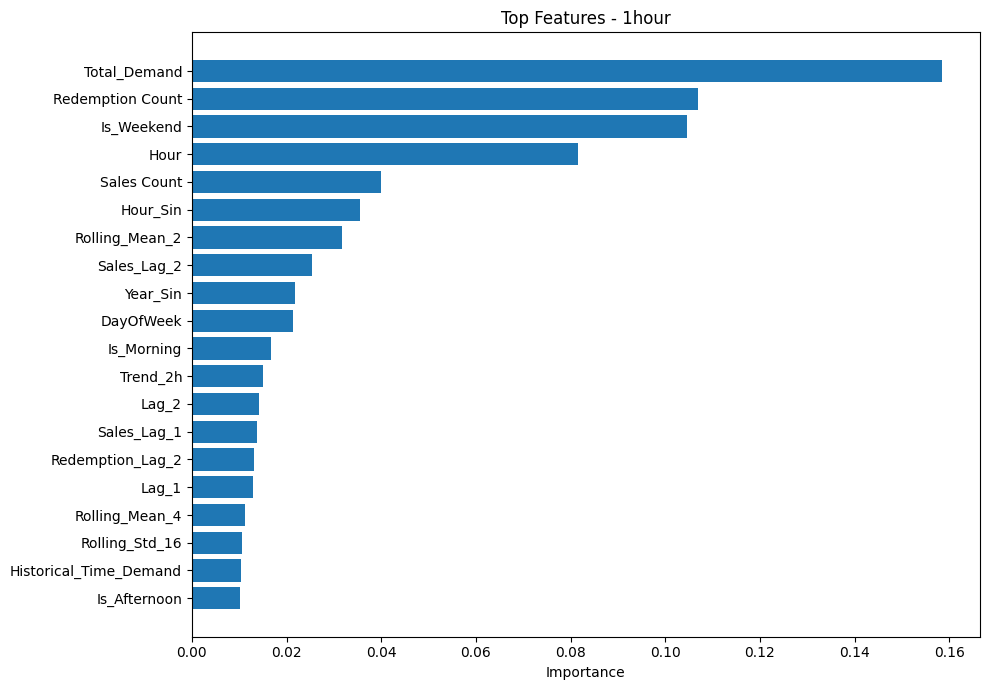

,Feature,Importance
0,Total_Demand,0.158583
2,Redemption Count,0.106981
14,Is_Weekend,0.104664
9,Hour,0.081554
1,Sales Count,0.039990
21,Hour_Sin,0.035569
43,Rolling_Mean_2,0.031818
36,Sales_Lag_2,0.025288
27,Year_Sin,0.021720
11,DayOfWeek,0.021322


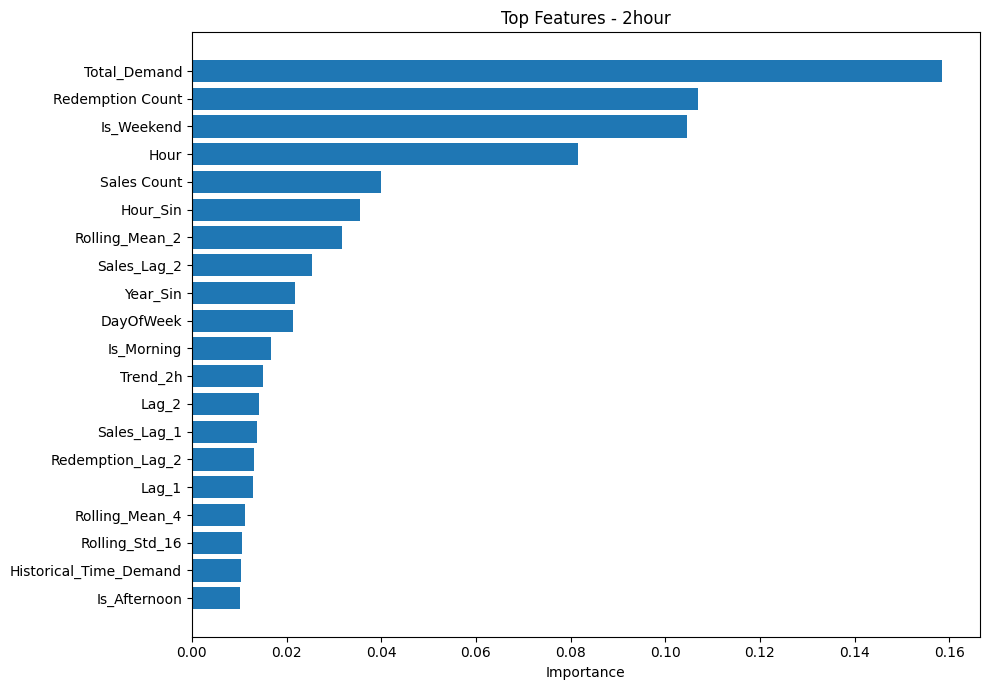

,Feature,Importance
0,Total_Demand,0.158583
2,Redemption Count,0.106981
14,Is_Weekend,0.104664
9,Hour,0.081554
1,Sales Count,0.039990
21,Hour_Sin,0.035569
43,Rolling_Mean_2,0.031818
36,Sales_Lag_2,0.025288
27,Year_Sin,0.021720
11,DayOfWeek,0.021322


In [46]:
for horizon in HORIZONS:

    best_model_name = best_models[horizon]

    model = trained_models[
        horizon
    ][best_model_name]

    if hasattr(model, "feature_importances_"):

        importance = pd.DataFrame({
            "Feature": FEATURES,
            "Importance": model.feature_importances_
        })

        importance = importance.sort_values(
            "Importance",
            ascending=False
        ).head(20)

        plt.figure(figsize=(10, 7))

        plt.barh(
            importance["Feature"][::-1],
            importance["Importance"][::-1]
        )

        plt.title(
            f"Top Features - {horizon}"
        )

        plt.xlabel("Importance")

        plt.tight_layout()
        plt.show()

        display(importance)

In [47]:
def normalize_series(series):

    low = series.quantile(0.05)
    high = series.quantile(0.95)

    return (
        (series - low) /
        (high - low + 1e-8)
    ).clip(0, 1)


df["Demand_Level_Score"] = normalize_series(
    df["Total_Demand"]
)

df["Momentum_Score"] = normalize_series(
    df["Demand_Momentum_15m"].fillna(0)
)

df["Volatility_Score"] = normalize_series(
    df["Demand_Volatility"].fillna(0)
)

df["Demand_Pressure_Index"] = (
    0.60 * df["Demand_Level_Score"] +
    0.25 * df["Momentum_Score"] +
    0.15 * df["Volatility_Score"]
)

df["Demand_Pressure_Index"] = (
    df["Demand_Pressure_Index"] * 100
).clip(0, 100)

display(
    df[
        [
            "Timestamp",
            "Total_Demand",
            "Demand_Momentum_15m",
            "Demand_Volatility",
            "Demand_Pressure_Index"
        ]
    ].tail(20)
)

,Timestamp,Total_Demand,Demand_Momentum_15m,Demand_Volatility,Demand_Pressure_Index
261518,2025-12-21 17:00:00,18,-31.0,0.655844,19.144028
261519,2025-12-21 17:15:00,15,6.0,0.612828,24.095045
261520,2025-12-21 17:30:00,46,-3.0,0.540338,25.400856
261521,2025-12-21 17:45:00,24,31.0,0.515653,27.815091
261522,2025-12-21 18:00:00,19,-22.0,0.538007,19.030104
261523,2025-12-21 18:15:00,10,-5.0,0.564200,21.029931
261524,2025-12-21 18:30:00,25,-9.0,0.564196,22.218114
261525,2025-12-21 18:45:00,3,15.0,0.512743,22.648577
261526,2025-12-21 19:00:00,6,-22.0,0.606626,18.421977
261527,2025-12-21 19:15:00,11,3.0,0.701539,24.389861


In [48]:
def classify_pressure(score):

    if score < 30:
        return "LOW"

    elif score < 60:
        return "MODERATE"

    elif score < 80:
        return "HIGH"

    else:
        return "CRITICAL"


df["Pressure_Level"] = (
    df["Demand_Pressure_Index"]
    .apply(classify_pressure)
)

display(
    df[
        [
            "Timestamp",
            "Demand_Pressure_Index",
            "Pressure_Level"
        ]
    ].tail(20)
)

,Timestamp,Demand_Pressure_Index,Pressure_Level
261518,2025-12-21 17:00:00,19.144028,LOW
261519,2025-12-21 17:15:00,24.095045,LOW
261520,2025-12-21 17:30:00,25.400856,LOW
261521,2025-12-21 17:45:00,27.815091,LOW
261522,2025-12-21 18:00:00,19.030104,LOW
261523,2025-12-21 18:15:00,21.029931,LOW
261524,2025-12-21 18:30:00,22.218114,LOW
261525,2025-12-21 18:45:00,22.648577,LOW
261526,2025-12-21 19:00:00,18.421977,LOW
261527,2025-12-21 19:15:00,24.389861,LOW


In [49]:
df["Next_1h_Demand"] = (
    df.groupby("Sequence_ID")["Total_Demand"]
    .shift(-4)
)

df["Next_1h_Spike"] = (
    df["Next_1h_Demand"] >= demand_q90
).astype(int)

spike_df = df.dropna(
    subset=FEATURES + ["Next_1h_Spike"]
).copy()

X_spike = spike_df[FEATURES]
y_spike = spike_df["Next_1h_Spike"]

split_spike = int(
    len(spike_df) * 0.80
)

X_spike_train = X_spike.iloc[:split_spike]
X_spike_test = X_spike.iloc[split_spike:]

y_spike_train = y_spike.iloc[:split_spike]
y_spike_test = y_spike.iloc[split_spike:]

print(
    X_spike_train.shape,
    X_spike_test.shape
)

(108175, 67) (27044, 67)


In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

spike_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

spike_model.fit(
    X_spike_train,
    y_spike_train
)

spike_pred = spike_model.predict(
    X_spike_test
)

print(
    "Spike Risk Accuracy:",
    accuracy_score(
        y_spike_test,
        spike_pred
    )
)

print(
    classification_report(
        y_spike_test,
        spike_pred
    )
)

Spike Risk Accuracy: 0.9554060050288419
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     22057
           1       0.89      0.86      0.88      4987

    accuracy                           0.96     27044
   macro avg       0.93      0.92      0.92     27044
weighted avg       0.95      0.96      0.96     27044



In [51]:
uncertainty_models = {}

for horizon in HORIZONS:

    best_model_name = best_models[horizon]

    model = trained_models[
        horizon
    ][best_model_name]

    predictions = model.predict(X_test)

    errors = (
        y_test[horizon].values -
        predictions
    )

    lower_error = np.quantile(
        errors,
        0.10
    )

    upper_error = np.quantile(
        errors,
        0.90
    )

    uncertainty_models[horizon] = {
        "model": model,
        "lower_error": lower_error,
        "upper_error": upper_error
    }

    print(
        horizon,
        "Lower error:",
        round(lower_error, 2),
        "Upper error:",
        round(upper_error, 2)
    )

15min Lower error: -52.79 Upper error: 163.93
30min Lower error: -37.72 Upper error: 157.6
1hour Lower error: -44.9 Upper error: 119.82
2hour Lower error: -62.46 Upper error: 64.49


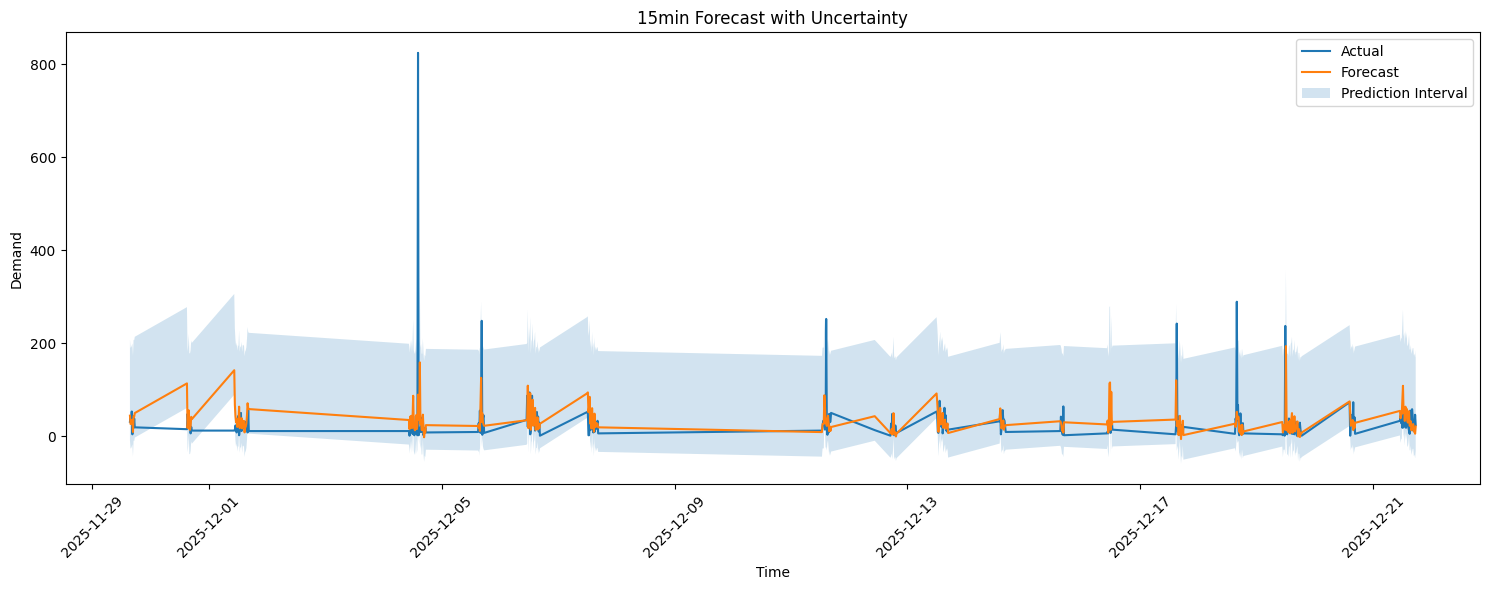

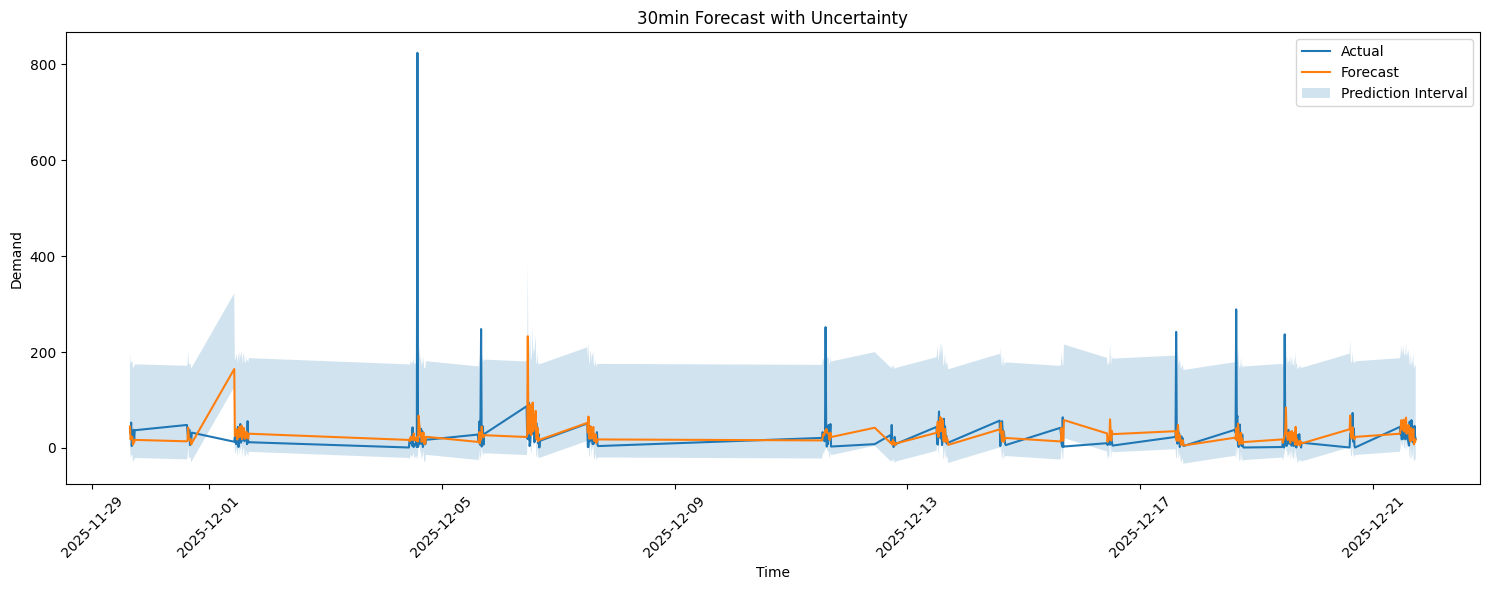

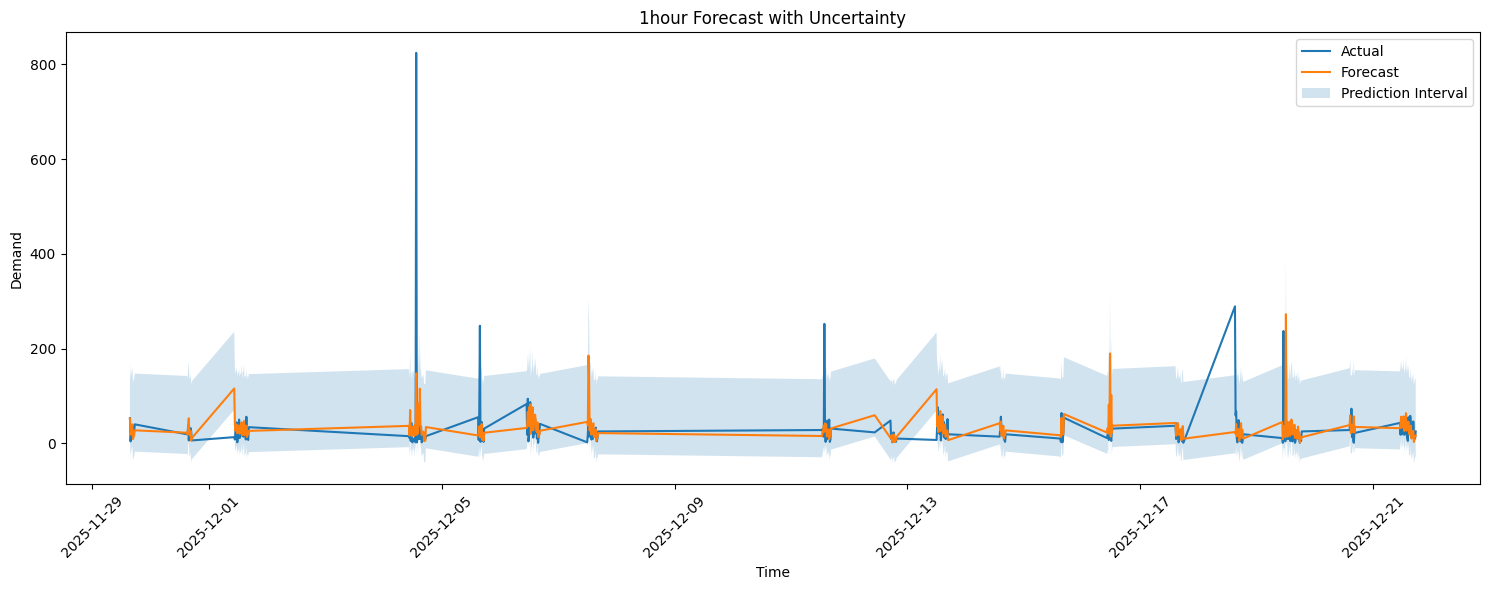

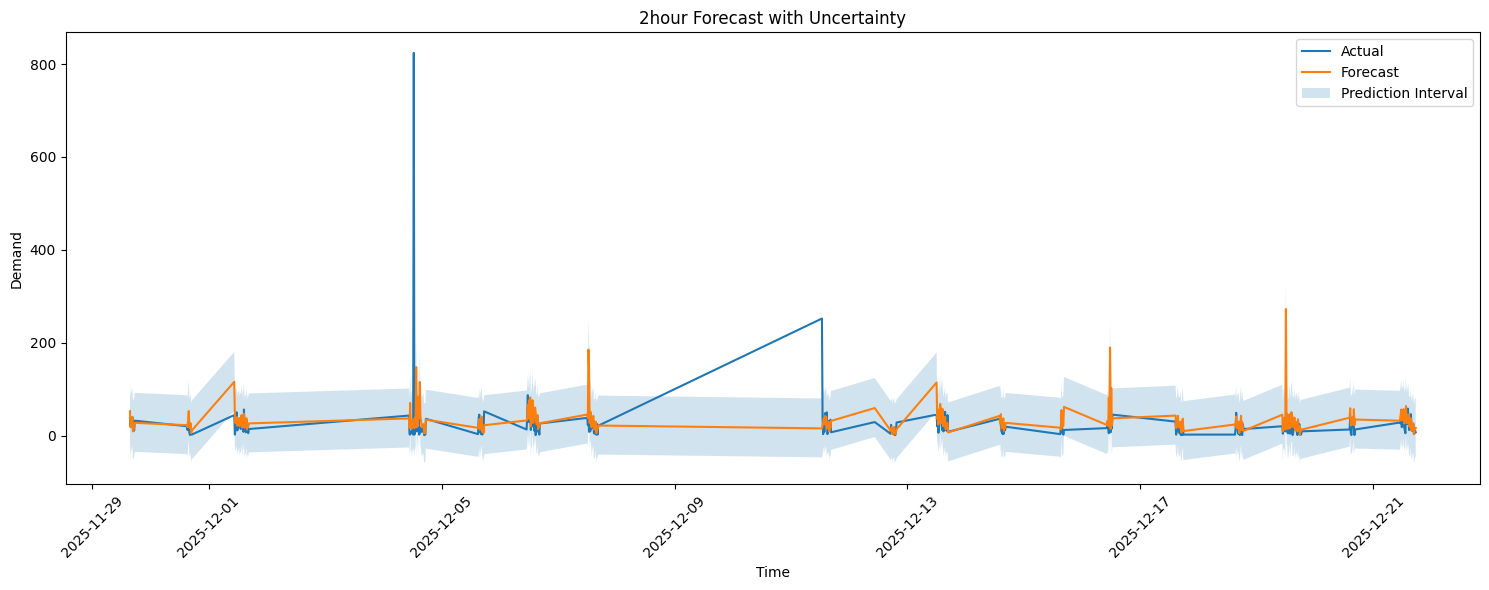

In [52]:
for horizon in HORIZONS:

    info = uncertainty_models[horizon]

    model = info["model"]

    predictions = model.predict(X_test)

    lower = (
        predictions +
        info["lower_error"]
    )

    upper = (
        predictions +
        info["upper_error"]
    )

    temp = pd.DataFrame({
        "Timestamp": test_df["Timestamp"].values,
        "Actual": y_test[horizon].values,
        "Prediction": predictions,
        "Lower": lower,
        "Upper": upper
    }).tail(300)

    plt.figure(figsize=(15, 6))

    plt.plot(
        temp["Timestamp"],
        temp["Actual"],
        label="Actual"
    )

    plt.plot(
        temp["Timestamp"],
        temp["Prediction"],
        label="Forecast"
    )

    plt.fill_between(
        temp["Timestamp"],
        temp["Lower"],
        temp["Upper"],
        alpha=0.2,
        label="Prediction Interval"
    )

    plt.title(
        f"{horizon} Forecast with Uncertainty"
    )

    plt.xlabel("Time")
    plt.ylabel("Demand")

    plt.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [53]:
def forecast_horizon(
    current_row,
    horizon
):

    best_model_name = best_models[horizon]

    model = trained_models[
        horizon
    ][best_model_name]

    X_current = current_row[FEATURES]

    prediction = model.predict(
        X_current
    )[0]

    info = uncertainty_models[horizon]

    lower = (
        prediction +
        info["lower_error"]
    )

    upper = (
        prediction +
        info["upper_error"]
    )

    return {
        "Horizon": horizon,
        "Model": best_model_name,
        "Forecast": max(0, prediction),
        "Lower": max(0, lower),
        "Upper": max(0, upper)
    }

In [54]:
latest_row = model_df.iloc[[-1]]

forecast_results = []

for horizon in HORIZONS:

    result = forecast_horizon(
        latest_row,
        horizon
    )

    forecast_results.append(result)

forecast_table = pd.DataFrame(
    forecast_results
)

display(forecast_table)

,Horizon,Model,Forecast,Lower,Upper
0,15min,Gradient Boosting,20.945996,0,184.872364
1,30min,Random Forest,17.464822,0,175.062644
2,1hour,XGBoost,16.237967,0,136.053030
3,2hour,XGBoost,16.237967,0,80.730088


In [55]:
def operational_action(
    forecast,
    historical_threshold
):

    ratio = forecast / (
        historical_threshold + 1e-8
    )

    if ratio < 0.50:
        return "NORMAL OPERATIONS"

    elif ratio < 0.75:
        return "MONITOR DEMAND"

    elif ratio < 1.00:
        return "PREPARE ADDITIONAL STAFF"

    elif ratio < 1.25:
        return "INCREASE OPERATIONAL READINESS"

    else:
        return "HIGH DEMAND ALERT"


forecast_table["Operational_Action"] = (
    forecast_table["Forecast"]
    .apply(
        lambda x:
        operational_action(
            x,
            demand_q90
        )
    )
)

display(forecast_table)

,Horizon,Model,Forecast,Lower,Upper,Operational_Action
0,15min,Gradient Boosting,20.945996,0,184.872364,NORMAL OPERATIONS
1,30min,Random Forest,17.464822,0,175.062644,NORMAL OPERATIONS
2,1hour,XGBoost,16.237967,0,136.053030,NORMAL OPERATIONS
3,2hour,XGBoost,16.237967,0,80.730088,NORMAL OPERATIONS


In [56]:
latest_timestamp = latest_row["Timestamp"].iloc[0]

latest_pressure = df[
    df["Timestamp"] == latest_timestamp
]["Demand_Pressure_Index"].iloc[0]

latest_pressure_level = df[
    df["Timestamp"] == latest_timestamp
]["Pressure_Level"].iloc[0]

print("="*70)
print("TORONTO ISLAND FERRY - PREDICTIVE DECISION REPORT")
print("="*70)

print("Current timestamp:", latest_timestamp)

print(
    f"Demand Pressure Index: "
    f"{latest_pressure:.2f}/100"
)

print(
    f"Pressure Level: "
    f"{latest_pressure_level}"
)

print("\nFORECASTS")
print("-"*70)

for _, row in forecast_table.iterrows():

    print(
        f"{row['Horizon']:>6} | "
        f"Forecast: {row['Forecast']:.0f} | "
        f"Range: {row['Lower']:.0f} - "
        f"{row['Upper']:.0f} | "
        f"{row['Operational_Action']}"
    )

TORONTO ISLAND FERRY - PREDICTIVE DECISION REPORT
Current timestamp: 2025-12-21 17:30:00
Demand Pressure Index: 25.40/100
Pressure Level: LOW

FORECASTS
----------------------------------------------------------------------
 15min | Forecast: 21 | Range: 0 - 185 | NORMAL OPERATIONS
 30min | Forecast: 17 | Range: 0 - 175 | NORMAL OPERATIONS
 1hour | Forecast: 16 | Range: 0 - 136 | NORMAL OPERATIONS
 2hour | Forecast: 16 | Range: 0 - 81 | NORMAL OPERATIONS


In [57]:
os.makedirs("ferry_models", exist_ok=True)

for horizon in trained_models:

    for model_name, model in trained_models[horizon].items():

        filename = (
            model_name
            .replace(" ", "_")
            .replace("/", "_")
        )

        path = (
            f"ferry_models/"
            f"{horizon}_{filename}.pkl"
        )

        joblib.dump(
            model,
            path
        )

print("All models saved.")

All models saved.


In [58]:
joblib.dump(
    FEATURES,
    "ferry_models/feature_list.pkl"
)

joblib.dump(
    best_models,
    "ferry_models/best_models.pkl"
)

joblib.dump(
    uncertainty_models,
    "ferry_models/uncertainty_models.pkl"
)

print("Project configuration saved.")

Project configuration saved.


In [59]:
final_results.to_csv(
    "ferry_model_comparison.csv",
    index=False
)

forecast_table.to_csv(
    "ferry_forecast_results.csv",
    index=False
)

df.to_csv(
    "ferry_engineered_dataset.csv",
    index=False
)

print("Files exported successfully.")

Files exported successfully.


In [60]:
from google.colab import files

files.download(
    "ferry_model_comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
files.download(
    "ferry_engineered_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>